
# Predictia supravietuirii pasagerilor de pe Titanic
Acest notebook implementeaza o problema de clasificare binara folosind datele despre pasagerii de pe Titanic.

Voi antrena urmatorii clasificatori:
- Logistic Regression
- Naive Bayes
- Support Vector Machine
- K-Nearest Neighbors
- Decision Trees
- Random Forest
- XGBoost
- CatBoost
- Explainable Boosting Machine (EBM)

Voi evalua modelele folosind:
- Accuracy
- Precision
- Recall
- F1-Score
- Area Under Curve (AUC) + ROC Curve
- Confusion Matrix

Voi optimiza hiperparametrii folosind:
- GridSearchCV
- BayesSearchCV

Voi explica modelele folosind:
- SHAP si LIME (exceptie EBM)



In [1]:
# importez toate librariile necesare

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import catboost as cb
from interpret.glassbox import ExplainableBoostingClassifier

import shap
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

## Incarcare dataset

In [2]:
# incarc dataset-ul Titanic
from sklearn.datasets import fetch_openml

# descarc direct dataset-ul
data = fetch_openml('titanic', version=1, as_frame=True)
df = data.frame

# vizualizez primele 5 randuri ca sa vad in mare cum arata datele
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Preprocesare date

In [3]:
# pastrez doar coloanele care sunt relevante pentru modelul nostru
df = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']]

# elimin toate randurile care au valori lipsa (NA) pentru ca pot incurca antrenarea modelului
df = df.dropna()

# codific coloanele de tip text pentru ca algoritmii de Machine Learning lucreaza doar cu numere, nu cu stringuri
# Sexul devine 0 pentru masculin si 1 pentru feminin
# la fel fac si pentru portul de imbarcare: S devine 0, C devine 1, Q devine 2
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# ma asigur ca variabila 'survived' este de tip intreg (int), adica doar 0 sau 1 fara zecimale
df['survived'] = df['survived'].astype(int)

# X contine toate informatiile despre pasager (input features)
# y contine ce vrem sa prezicem adica daca pasagerul a supravietuit sau nu
X = df.drop('survived', axis=1)
y = df['survived']

# impart datele in set de antrenare si set de test
# 80% din date merg la antrenare si 20% la testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standarizez datele pentru ca diferentele de scara dintre coloane pot afecta performanta modelelor
# standarizarea inseamna ca aducem toate variabilele la aceeasi scara: media devine 0 si deviatia standard 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Functie pentru evaluarea unui model de clasificare

In [4]:
def evaluate_model(name, model, X_test, y_test):
    # precizez clasele pe setul de date
    y_pred = model.predict(X_test)
    
    # calc probabilitatile pentru clasa pozitiva (1)
    # daca modelul are predict_proba, folosesc predict_proba, daca nu are folosesc decision_function
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    # calculez metricile de evaluare
    acc = accuracy_score(y_test, y_pred)  # cat de multe predictii sunt corecte
    prec = precision_score(y_test, y_pred)  # dintre cele prezise ca fiind pozitive, cate sunt corecte
    rec = recall_score(y_test, y_pred)  # dintre cele care sunt cu adevarat pozitive, cate au fost prezise corect
    f1 = f1_score(y_test, y_pred)  # media armonica intre precizie si recall
    auc = roc_auc_score(y_test, y_proba)  # aria sub curba ROC, cat de bine separa clasele
    
    # afisez rez in consola
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")
    
    # desenez curba ROC
    # ROC = grafic care evalueaza performanta unui model de clasificare, care arata cum se schimba sensibilitatea si rata falselor pozitive pe masura ce variam pragul de decizie
    # cu cat aria sub curba ROC (AUC) este mai mare, cu atat modelul este mai bun
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.show()
    
    # calc si afisez matricea de confuzie (tabel care ne arata cat de bine a facut predictii modelul de clasificare)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## Regresia Logistica

Model: Logistic Regression
Accuracy: 0.7799
Precision: 0.7794
Recall: 0.6310
F1 Score: 0.6974
AUC: 0.7953


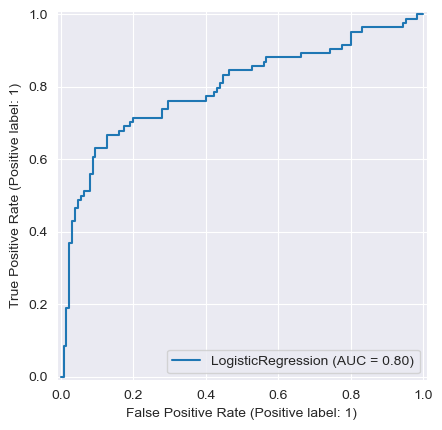

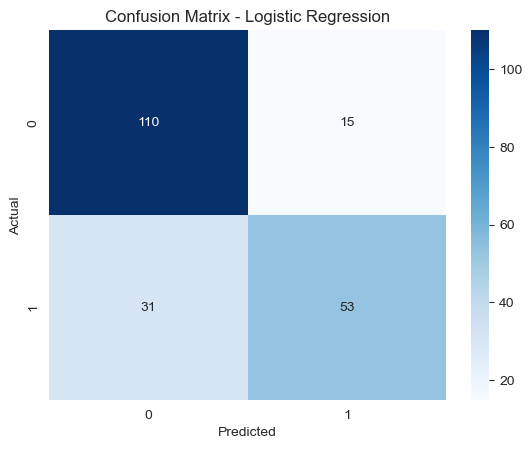

In [5]:
# Regresia Logistica este un model de clasificare binara ce estimeaza probabilitatea de apartenenta la clasa pozitiva

lr = LogisticRegression()
lr.fit(X_train, y_train)
evaluate_model("Logistic Regression", lr, X_test, y_test)

# Rezultate:
    # Accuracy: 77.99% - aproape 78% dintre predictii sunt corecte
    # Precision: 77.94% - 77.94% din cazurile prezise ca pozitive sunt corecte
    # Recall: 63.10% - detecteaza 63.1% din cazurile pozitive
    # F1 Score: 69.74% - echilibrul intre precizie si recall
    # AUC: 79.53% - modelul se descurca destul de bine in diferentierea claselor

## Naive Bayes

Model: Naive Bayes
Accuracy: 0.7751
Precision: 0.7467
Recall: 0.6667
F1 Score: 0.7044
AUC: 0.7881


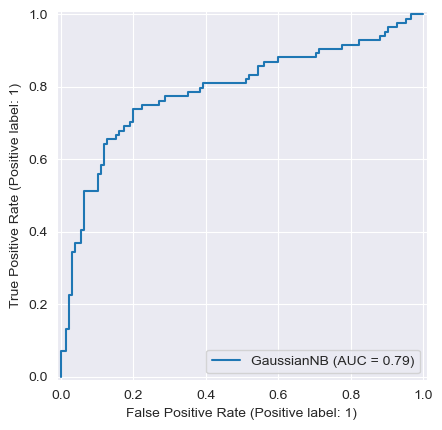

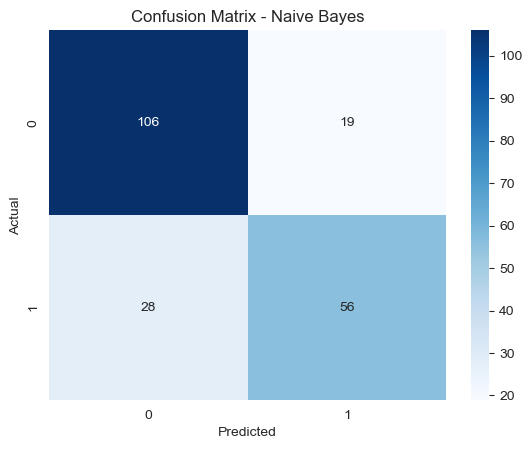

In [6]:
# Naive Bayes este un model probabilistic care foloseste teorema lui Bayes si presupune ca caracteristicile sunt independente.

nb = GaussianNB()
nb.fit(X_train, y_train)
evaluate_model("Naive Bayes", nb, X_test, y_test)

# Rezultate:
    # Accuracy: 77.51% - aproape 78% dintre predictii sunt corecte
    # Precision: 74.67% din cazurile prezise ca pozitive sunt corecte
    # Recall: 66.67% - detecteaza 66.67% din cazurile pozitive
    # F1 Score: 70.44% - echilibrul intre precizie si recall este decent
    # AUC: 78.81% - performanta buna in diferentierea claselor

## Support Vector Machine

Model: Support Vector Machine
Accuracy: 0.7608
Precision: 0.8036
Recall: 0.5357
F1 Score: 0.6429
AUC: 0.7979


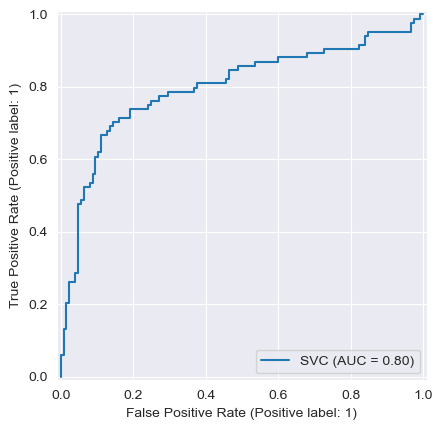

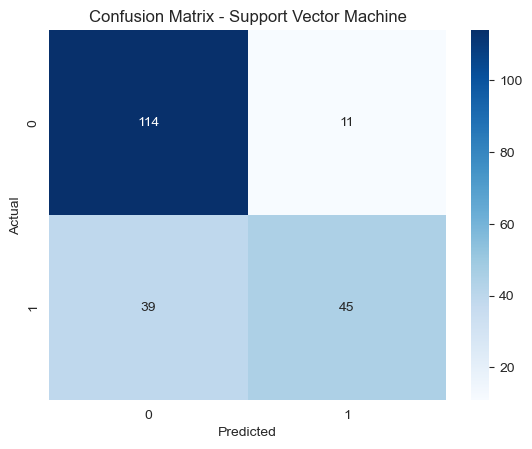

In [7]:
# Support Vector Machine (SVM) este un model de clasificare care cauta sa gaseasca o hiperplana optima ce separa clasele cat mai bine

svm = SVC(probability=True)
svm.fit(X_train, y_train)
evaluate_model("Support Vector Machine", svm, X_test, y_test)

# Rezultate:
    # Accuracy: 76.08% - aproape 76% dintre predictii sunt corecte
    # Precision: 80.36% din cazurile prezise ca pozitive sunt corecte
    # Recall: 53.57% - modelul identifica doar 53.57% din cazurile pozitive
    # F1 Score: 64.29% - echilibrul intre precizie si recall este decent
    # AUC: 79.79% - performanta buna in diferentierea claselor

## K-Nearest Neighbors

Model: K-Nearest Neighbors
Accuracy: 0.7560
Precision: 0.7391
Recall: 0.6071
F1 Score: 0.6667
AUC: 0.7851


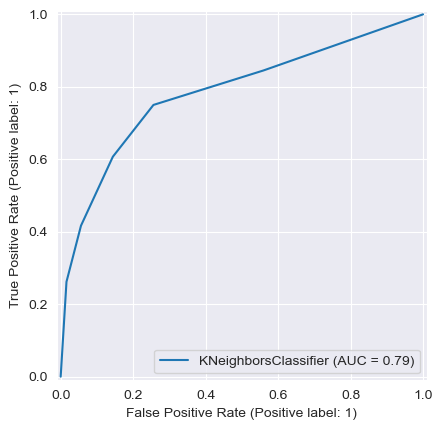

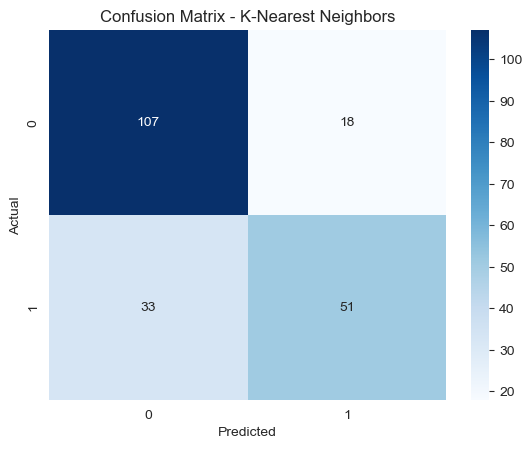

In [8]:
# K-Nearest Neighbors este un model de clasificare bazat pe distanta dintre instantele de date si etichetele celor mai apropiate k vecini

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
evaluate_model("K-Nearest Neighbors", knn, X_test, y_test)

## Decision Tree

Model: Decision Tree
Accuracy: 0.7608
Precision: 0.7361
Recall: 0.6310
F1 Score: 0.6795
AUC: 0.7312


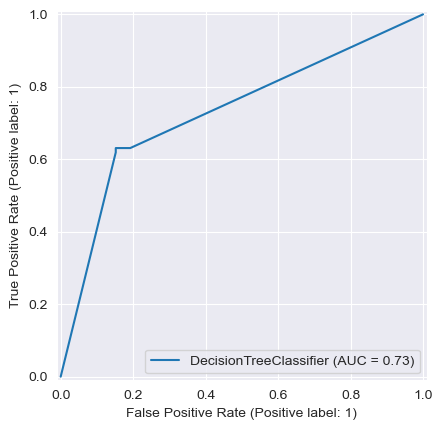

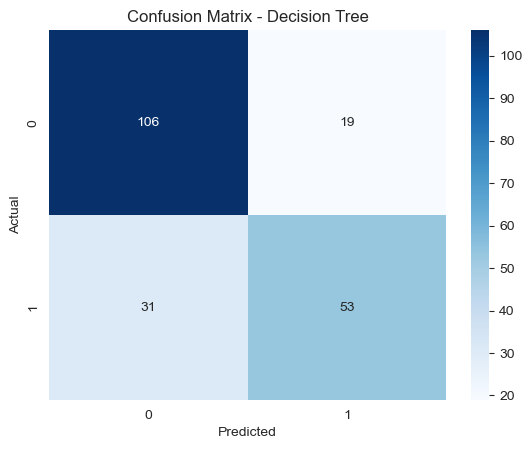

In [9]:
# Decision Tree este un model de clasificare care imparte datele in subgrupuri pe baza trasaturilor, construind o structura de tip arbore pentru a face predictii

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
evaluate_model("Decision Tree", dt, X_test, y_test)

## Random Forest

Model: Random Forest
Accuracy: 0.7847
Precision: 0.8095
Recall: 0.6071
F1 Score: 0.6939
AUC: 0.8168


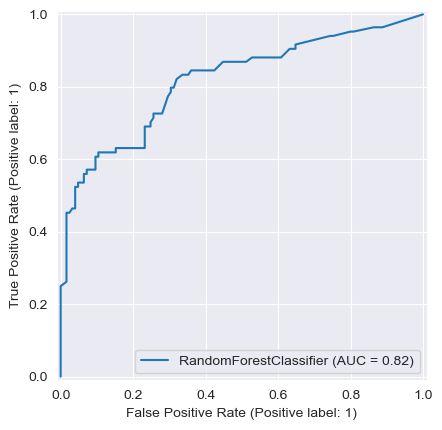

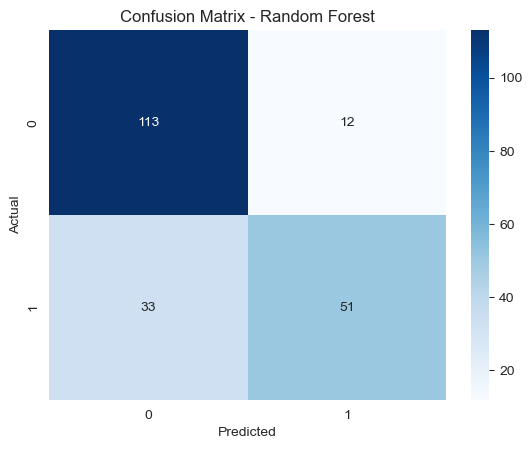

In [10]:
# Random Forest este un model de clasificare ce folosește mai multi arbori de decizie pentru a imbunatati performanta si a reduce overfitting-ul

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
evaluate_model("Random Forest", rf, X_test, y_test)

## XGBoost

Model: XGBoost
Accuracy: 0.7847
Precision: 0.8197
Recall: 0.5952
F1 Score: 0.6897
AUC: 0.8175


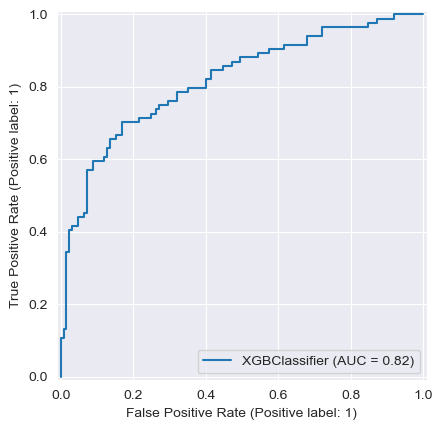

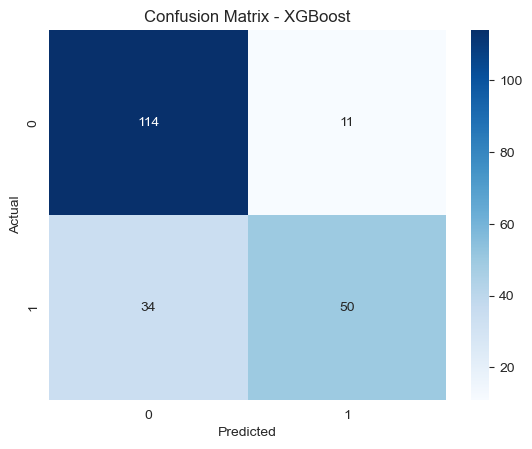

In [11]:
# XGBoost este un model de invatare automata care foloseste boosting pentru a imbunatati performanta prin combinarea mai multor arbori de decizie

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
evaluate_model("XGBoost", xgb_model, X_test, y_test)

## CatBoost

Model: CatBoost
Accuracy: 0.7751
Precision: 0.8136
Recall: 0.5714
F1 Score: 0.6713
AUC: 0.8270


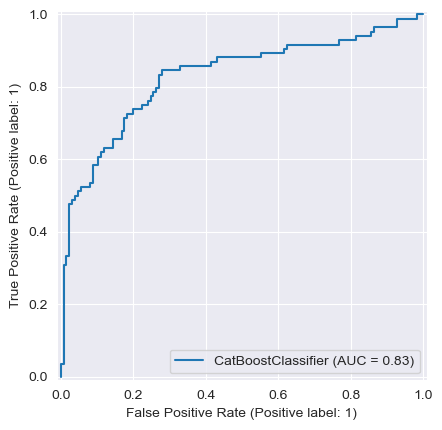

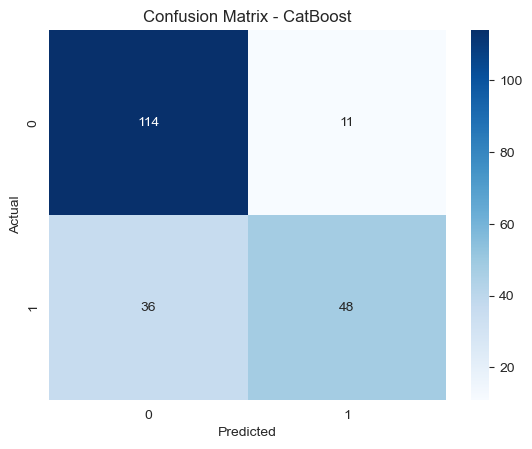

In [13]:
# CatBoost este un model de invatare automata bazat pe boosting, optimizat pentru a lucra eficient cu variabile categoriale

cat_model = cb.CatBoostClassifier(verbose=0)
cat_model.fit(X_train, y_train)
evaluate_model("CatBoost", cat_model, X_test, y_test)

## Explainable Boosting Machine

Model: Explainable Boosting Machine
Accuracy: 0.7943
Precision: 0.8254
Recall: 0.6190
F1 Score: 0.7075
AUC: 0.8266


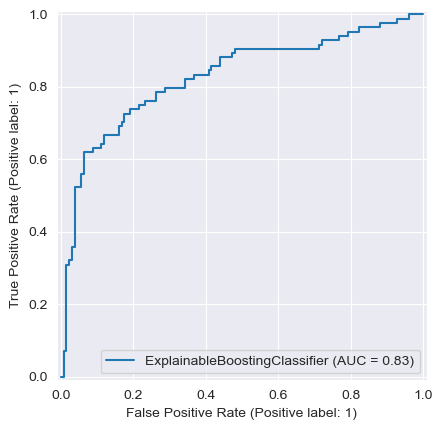

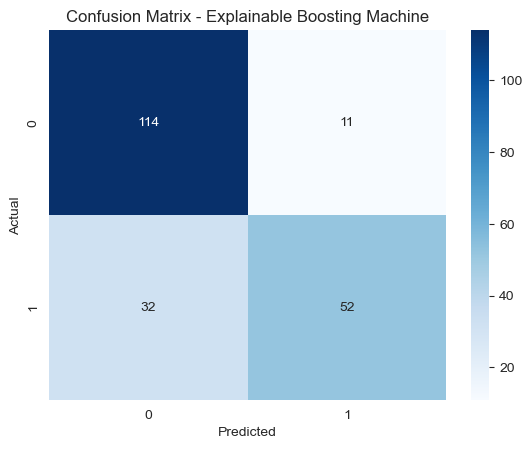

<!-- http://127.0.0.1:7001/2103369318864/ -->

In [14]:
# Explainable Boosting Machine (EBM) este un model de invatare automata care combina performanta modelelor complexe cu interpretabilitatea, fiind un model de tip "glass-box" (transparent)

ebm = ExplainableBoostingClassifier()
ebm.fit(X_train, y_train)
evaluate_model("Explainable Boosting Machine", ebm, X_test, y_test)

# grafic importanta caracteristicilor
ebm_global = ebm.explain_global()
from interpret import show
show(ebm_global)

# Concluzie: EBM ofera o performanta buna, cu avantajul suplimentar al interpretabilitatii, fiind util in aplicatii unde este important sa intelegem deciziile modelului.

## SHAP & LIME

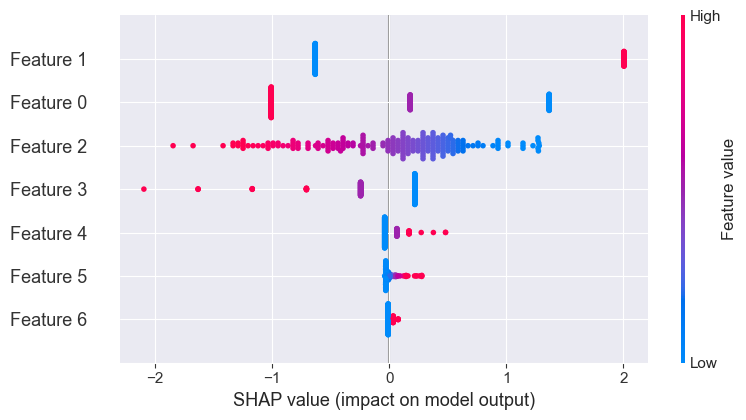

In [16]:
# SHAP (shapley additive explanations) pentru logistic regression
# SHAP explica predictiile modelului atribuit fiecarei caracteristici un impact specific asupra rezultatului

# calculam valorile shap pentru datele de test si afisam un summary plot pentru a vizualiza importanta caracteristicilor
explainer = shap.Explainer(lr, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

# LIME (local interpretable model-agnostic explanations) pentru logistic regression
# LIME creeaza o explicatie locala pentru o instanta, adica expune cum un model ia decizii pentru un caz specific
explainer_lime = lime.lime_tabular.LimeTabularExplainer(X_train, feature_names=list(df.columns[:-1]), class_names=['not survived', 'survived'], discretize_continuous=True)
i = 0  # alegem prima instanta din setul de test
exp = explainer_lime.explain_instance(X_test[i], lr.predict_proba, num_features=5)

# salvam explicatia lime intr-un fisier html pentru a putea fi vizualizata
exp.save_to_file('lime_explanation.html')

Cei mai buni parametri:  {'C': 1, 'solver': 'saga'}
Cel mai bun model:  LogisticRegression(C=1, solver='saga')
Model: Logistic Regression with GridSearch
Accuracy: 0.7799
Precision: 0.7794
Recall: 0.6310
F1 Score: 0.6974
AUC: 0.7952


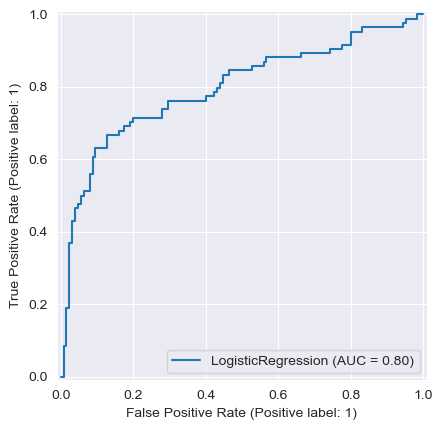

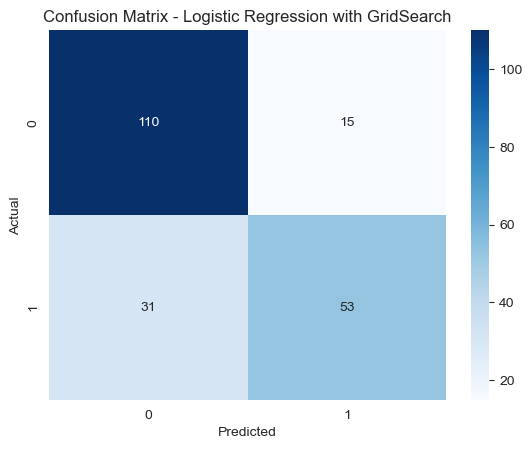

In [17]:
from sklearn.model_selection import GridSearchCV

# Setezi parametrii pentru modelul de Logistic Regression
param_grid = {
    'C': [0.1, 1, 10],  # Parametru pentru logistic regression
    'solver': ['liblinear', 'saga']  # Alegerea solver-ului
}

# GridSearchCV pentru Logistic Regression
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Afli cei mai buni parametri si cel mai bun model
print("Cei mai buni parametri: ", grid_search.best_params_)
print("Cel mai bun model: ", grid_search.best_estimator_)

# Evaluezi performanta modelului optimizat
evaluate_model("Logistic Regression with GridSearch", grid_search.best_estimator_, X_test, y_test)


Cei mai buni parametri:  OrderedDict({'C': 2.8982264461081377, 'solver': 'liblinear'})
Cel mai bun model:  LogisticRegression(C=2.8982264461081377, solver='liblinear')
Model: Logistic Regression with BayesSearch
Accuracy: 0.7799
Precision: 0.7794
Recall: 0.6310
F1 Score: 0.6974
AUC: 0.7951


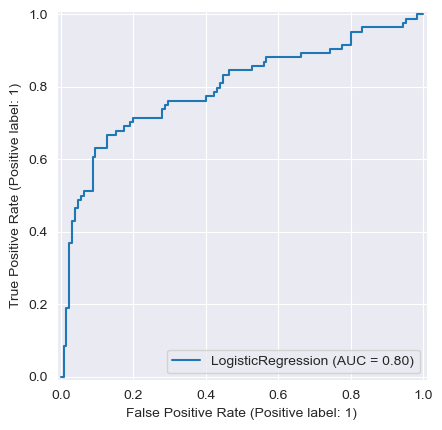

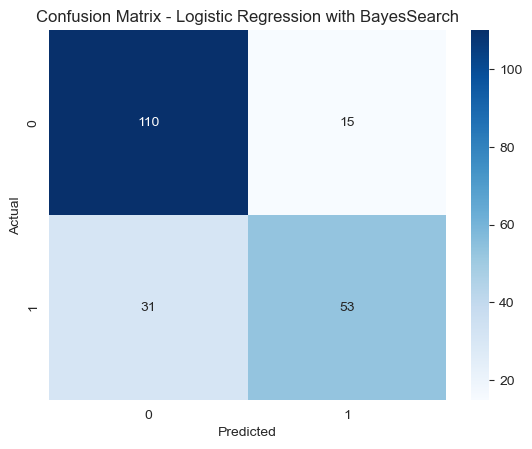

In [18]:
from skopt import BayesSearchCV

# setez parametrii pentru modelul de Logistic Regression
param_space = {
    'C': (0.1, 10.0, 'uniform'),  # param pentru logistic regression
    'solver': ['liblinear', 'saga']  # aleg solver-ului
}

# BayesSearchCV pentru Logistic Regression
bayes_search = BayesSearchCV(LogisticRegression(), param_space, n_iter=50, cv=5)
bayes_search.fit(X_train, y_train)

# aflu cei mai buni parametri si cel mai bun model
print("Cei mai buni parametri: ", bayes_search.best_params_)
print("Cel mai bun model: ", bayes_search.best_estimator_)

# evaluez performanta modelului optimizat
evaluate_model("Logistic Regression with BayesSearch", bayes_search.best_estimator_, X_test, y_test)
